# Heat Exchanger Examples

This notebook demonstrates the heat exchanger unit operations in difflow:

1. **Simple Examples**: Heaters and coolers with utilities
2. **Two-Stream Heat Exchangers**: Counter-current and co-current
3. **Design and Sizing**: LMTD and effectiveness-NTU methods
4. **Advanced Example**: Reactor with feed preheating (heat integration)
5. **Optimization**: Minimize utility cost with gradient-based optimization

In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from difflow import (
    make_stream,
    Heater, HeaterParams,
    Cooler, CoolerParams,
    CounterCurrentHX, CoCurrentHX, HeatExchangerParams,
    log_mean_temperature_difference,
    design_heat_exchanger,
    size_heat_exchanger,
    CSTR, CSTRParams,
    IdealThermo, SpeciesData,
)

# Enable float64 for better numerical precision
jax.config.update('jax_enable_x64', True)

W0000 00:00:1765976276.657875 13763662 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1765976276.668162 13763662 service.cc:145] XLA service 0x600001be4500 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765976276.668177 13763662 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1765976276.669392 13763662 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1765976276.669404 13763662 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


## 1. Simple Examples: Heaters and Coolers

Single-stream heat exchangers with utilities (steam, cooling water, etc.)

### 1.1 Heater with Specified Duty

In [2]:
# Create a process stream
feed = make_stream({"methanol": 10.0, "water": 5.0}, T=300.0, P=101325.0)

# Heater with 50 kW duty
# Cp = 75 J/(mol·K) is typical for organic liquids
heater = Heater(HeaterParams(duty=50000.0, Cp=75.0))
heated, info = heater(feed)

print("Heater with Specified Duty")
print(f"  Inlet temperature:  {float(info['T_in']):.1f} K")
print(f"  Outlet temperature: {float(info['T_out']):.1f} K")
print(f"  Heat duty:          {float(info['Q'])/1000:.1f} kW")
print(f"  Temperature rise:   {float(info['T_out'] - info['T_in']):.1f} K")

Heater with Specified Duty
  Inlet temperature:  300.0 K
  Outlet temperature: 344.4 K
  Heat duty:          50.0 kW
  Temperature rise:   44.4 K


### 1.2 Heater with Specified Outlet Temperature

In [3]:
# Heat feed to 350 K
heater = Heater(HeaterParams(T_out=350.0, Cp=75.0))
heated, info = heater(feed)

print("Heater with Specified Outlet Temperature")
print(f"  Target temperature: 350.0 K")
print(f"  Required duty:      {float(info['Q'])/1000:.2f} kW")

Heater with Specified Outlet Temperature
  Target temperature: 350.0 K
  Required duty:      56.25 kW


### 1.3 Heater Rating Mode (with UA and utility temperature)

In [4]:
# Heater with steam at 423 K (150°C, ~5 bar steam)
# UA = 2000 W/K (typical for shell-and-tube)
heater = Heater(HeaterParams(UA=2000.0, T_utility=423.0, Cp=75.0))
heated, info = heater(feed)

print("Heater Rating Mode")
print(f"  Steam temperature:  {423.0} K ({423-273:.0f}°C)")
print(f"  UA:                 {2000} W/K")
print(f"  Outlet temperature: {float(info['T_out']):.1f} K")
print(f"  Heat duty:          {float(info['Q'])/1000:.2f} kW")
print(f"  LMTD:               {float(info['LMTD']):.1f} K")

Heater Rating Mode
  Steam temperature:  423.0 K (150°C)
  UA:                 2000 W/K
  Outlet temperature: 402.2 K
  Heat duty:          114.99 kW
  LMTD:               57.5 K


### 1.4 Cooler Example

In [5]:
# Hot stream from reactor
hot_product = make_stream({"product": 8.0, "byproduct": 2.0}, T=420.0, P=101325.0)

# Cool to 320 K using cooling water (utility at 298 K)
cooler = Cooler(CoolerParams(T_out=320.0, T_utility=298.0, Cp=80.0))
cooled, info = cooler(hot_product)

print("Cooler Example")
print(f"  Inlet temperature:  {float(info['T_in']):.1f} K")
print(f"  Outlet temperature: {float(info['T_out']):.1f} K")
print(f"  Heat removed:       {float(info['Q'])/1000:.2f} kW")
print(f"  LMTD:               {float(info['LMTD']):.1f} K")
print(f"  Required UA:        {float(info['UA_required']):.1f} W/K")

Cooler Example
  Inlet temperature:  420.0 K
  Outlet temperature: 320.0 K
  Heat removed:       80.00 kW
  LMTD:               58.4 K
  Required UA:        1370.4 W/K


## 2. Two-Stream Heat Exchangers

Process-to-process heat exchange for heat integration.

### 2.1 Counter-Current Heat Exchanger

In [6]:
# Hot product stream leaving reactor
hot_stream = make_stream({"product": 10.0}, T=450.0, P=101325.0)

# Cold feed stream entering process
cold_stream = make_stream({"feed": 10.0}, T=300.0, P=101325.0)

# Counter-current heat exchanger
hx = CounterCurrentHX(HeatExchangerParams(
    UA=1500.0,      # W/K
    Cp_hot=75.0,    # J/(mol·K)
    Cp_cold=75.0,
))

hot_out, cold_out, info = hx(hot_stream, cold_stream)

print("Counter-Current Heat Exchanger")
print(f"  Hot side:  {float(info['T_hot_in']):.1f} K → {float(info['T_hot_out']):.1f} K")
print(f"  Cold side: {float(info['T_cold_in']):.1f} K → {float(info['T_cold_out']):.1f} K")
print(f"  Heat transferred: {float(info['Q'])/1000:.2f} kW")
print(f"  Effectiveness:    {float(info['effectiveness']):.3f}")
print(f"  NTU:              {float(info['NTU']):.2f}")
print(f"  LMTD:             {float(info['LMTD']):.1f} K")
print(f"  Approach temp:    {float(info['approach']):.1f} K")

Counter-Current Heat Exchanger
  Hot side:  450.0 K → 350.0 K
  Cold side: 300.0 K → 400.0 K
  Heat transferred: 75.00 kW
  Effectiveness:    0.667
  NTU:              2.00
  LMTD:             50.0 K
  Approach temp:    50.0 K


### 2.2 Co-Current vs Counter-Current Comparison

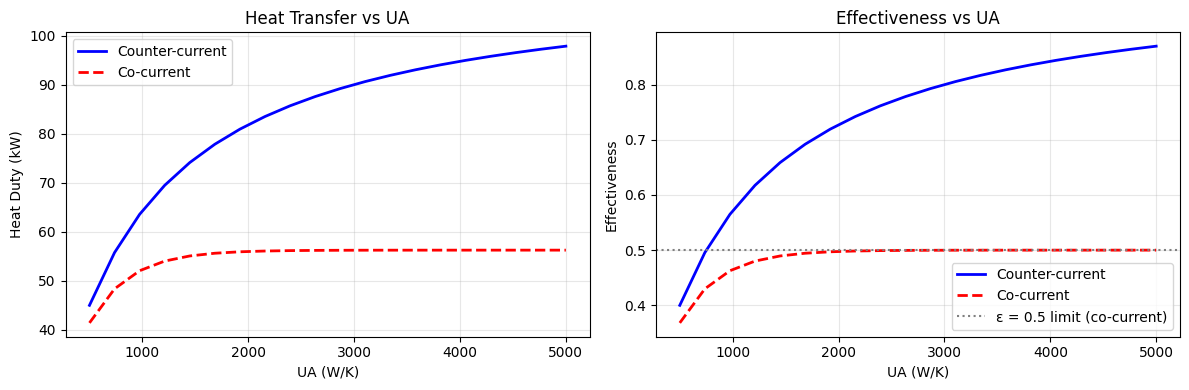


Note: Counter-current always achieves higher effectiveness for the same UA.
Co-current is limited to ε ≤ 0.5 for balanced flows (Cr = 1).


In [7]:
# Compare at same UA
UA_values = jnp.linspace(500, 5000, 20)

Q_counter = []
Q_co = []
eps_counter = []
eps_co = []

for UA in UA_values:
    # Counter-current
    hx_counter = CounterCurrentHX(HeatExchangerParams(Cp_hot=75.0, Cp_cold=75.0))
    _, _, info_counter = hx_counter(hot_stream, cold_stream, UA=float(UA))
    Q_counter.append(float(info_counter['Q']))
    eps_counter.append(float(info_counter['effectiveness']))
    
    # Co-current
    hx_co = CoCurrentHX(HeatExchangerParams(Cp_hot=75.0, Cp_cold=75.0))
    _, _, info_co = hx_co(hot_stream, cold_stream, UA=float(UA))
    Q_co.append(float(info_co['Q']))
    eps_co.append(float(info_co['effectiveness']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(UA_values, jnp.array(Q_counter)/1000, 'b-', label='Counter-current', linewidth=2)
axes[0].plot(UA_values, jnp.array(Q_co)/1000, 'r--', label='Co-current', linewidth=2)
axes[0].set_xlabel('UA (W/K)')
axes[0].set_ylabel('Heat Duty (kW)')
axes[0].set_title('Heat Transfer vs UA')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(UA_values, eps_counter, 'b-', label='Counter-current', linewidth=2)
axes[1].plot(UA_values, eps_co, 'r--', label='Co-current', linewidth=2)
axes[1].axhline(y=0.5, color='gray', linestyle=':', label='ε = 0.5 limit (co-current)')
axes[1].set_xlabel('UA (W/K)')
axes[1].set_ylabel('Effectiveness')
axes[1].set_title('Effectiveness vs UA')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: Counter-current always achieves higher effectiveness for the same UA.")
print("Co-current is limited to ε ≤ 0.5 for balanced flows (Cr = 1).")

## 3. Heat Exchanger Design and Sizing

Calculate required area from process specifications.

### 3.1 LMTD Method (Given Temperatures)

In [8]:
# Design specifications
Q_design = 100000.0  # 100 kW
T_hot_in = 450.0     # K
T_hot_out = 380.0    # K  
T_cold_in = 300.0    # K
T_cold_out = 360.0   # K
U = 500.0            # W/(m²·K) - typical for liquid-liquid

result = design_heat_exchanger(
    Q=jnp.array(Q_design),
    T_hot_in=jnp.array(T_hot_in),
    T_hot_out=jnp.array(T_hot_out),
    T_cold_in=jnp.array(T_cold_in),
    T_cold_out=jnp.array(T_cold_out),
    U=jnp.array(U),
    flow_config="counter_current",
)

print("LMTD Design Method")
print(f"  Heat duty:     {Q_design/1000:.1f} kW")
print(f"  Hot side:      {T_hot_in:.0f} K → {T_hot_out:.0f} K")
print(f"  Cold side:     {T_cold_in:.0f} K → {T_cold_out:.0f} K")
print(f"  U:             {U:.0f} W/(m²·K)")
print("\nResults:")
print(f"  LMTD:          {float(result['LMTD']):.1f} K")
print(f"  Required UA:   {float(result['UA']):.1f} W/K")
print(f"  Required Area: {float(result['A']):.2f} m²")

LMTD Design Method
  Heat duty:     100.0 kW
  Hot side:      450 K → 380 K
  Cold side:     300 K → 360 K
  U:             500 W/(m²·K)

Results:
  LMTD:          84.9 K
  Required UA:   1177.8 W/K
  Required Area: 2.36 m²


### 3.2 Effectiveness-NTU Method (Given Flow Rates)

In [9]:
# Design from heat capacity rates
C_hot = 750.0   # W/K (10 mol/s × 75 J/mol·K)
C_cold = 600.0  # W/K (8 mol/s × 75 J/mol·K)

result = size_heat_exchanger(
    Q=jnp.array(50000.0),        # 50 kW
    T_hot_in=jnp.array(450.0),
    T_cold_in=jnp.array(300.0),
    C_hot=jnp.array(C_hot),
    C_cold=jnp.array(C_cold),
    U=jnp.array(500.0),
    flow_config="counter_current",
)

print("Effectiveness-NTU Sizing Method")
print(f"  Heat duty:       {50.0:.1f} kW")
print(f"  C_hot:           {C_hot:.0f} W/K")
print(f"  C_cold:          {C_cold:.0f} W/K")
print(f"  Cr (Cmin/Cmax):  {float(result['Cr']):.3f}")
print("\nResults:")
print(f"  Effectiveness:   {float(result['effectiveness']):.3f}")
print(f"  NTU:             {float(result['NTU']):.2f}")
print(f"  Required UA:     {float(result['UA']):.1f} W/K")
print(f"  Required Area:   {float(result['A']):.2f} m²")
print(f"  T_hot_out:       {float(result['T_hot_out']):.1f} K")
print(f"  T_cold_out:      {float(result['T_cold_out']):.1f} K")

Effectiveness-NTU Sizing Method
  Heat duty:       50.0 kW
  C_hot:           750 W/K
  C_cold:          600 W/K
  Cr (Cmin/Cmax):  0.800

Results:
  Effectiveness:   0.556
  NTU:             1.12
  Required UA:     669.4 W/K
  Required Area:   1.34 m²
  T_hot_out:       383.3 K
  T_cold_out:      383.3 K


## 4. Advanced Example: Reactor with Feed Preheating

A common heat integration scenario: use hot reactor effluent to preheat cold feed.

In [10]:
# Define species for reactor
species_data = {
    "A": SpeciesData("A", MW=100.0, Cp_coeffs=(75.0, 0.0, 0.0, 0.0),
                     Hvap_coeffs=(35000.0, 0.38, 500.0),
                     antoine_coeffs=(10.0, 3000.0, -50.0), Hf=0.0),
    "B": SpeciesData("B", MW=100.0, Cp_coeffs=(80.0, 0.0, 0.0, 0.0),
                     Hvap_coeffs=(30000.0, 0.38, 450.0),
                     antoine_coeffs=(10.0, 2800.0, -40.0), Hf=-50000.0),
}
thermo = IdealThermo(species_data)

# Reaction kinetics: A → B (exothermic)
def rate_fn(C, T, params):
    k = params["k0"] * jnp.exp(-params["Ea"] / (8.314 * T))
    return jnp.array([k * C["A"]])

stoich = jnp.array([[-1.0], [+1.0]])  # A → B
rate_params = {"k0": jnp.array(1e8), "Ea": jnp.array(60000.0)}

### 4.1 Without Heat Integration (Base Case)

In [11]:
# Cold feed at ambient temperature
cold_feed = make_stream({"A": 10.0, "B": 0.0}, T=298.0, P=101325.0)

# Heat feed to reactor temperature with steam
T_reactor = 400.0  # K
heater_feed = Heater(HeaterParams(T_out=T_reactor, Cp=75.0))
hot_feed, heater_info = heater_feed(cold_feed)

# Reactor (isothermal)
cstr = CSTR(
    CSTRParams(
        V=jnp.array(2.0),
        rate_fn=rate_fn,
        stoich=stoich,
        rate_params=rate_params,
        species_order=["A", "B"],
    ),
    thermo=thermo,
    mode="isothermal",
)

product, reactor_info = cstr(hot_feed, T_spec=T_reactor)

# Cool product to storage temperature
T_storage = 310.0  # K
cooler_product = Cooler(CoolerParams(T_out=T_storage, Cp=77.5))  # avg Cp
cooled_product, cooler_info = cooler_product(product)

print("Base Case: No Heat Integration")
print(f"\nFeed Heating:")
print(f"  Steam duty:        {float(heater_info['Q'])/1000:.2f} kW")
print(f"\nReactor:")
print(f"  Conversion:        {float(reactor_info['conversion']['A'])*100:.1f}%")
print(f"  Reactor heat duty: {float(reactor_info['Q'])/1000:.2f} kW (cooling needed)")
print(f"\nProduct Cooling:")
print(f"  Cooling duty:      {float(cooler_info['Q'])/1000:.2f} kW")
print(f"\nTotal Utilities:")
print(f"  Heating (steam):   {float(heater_info['Q'])/1000:.2f} kW")
print(f"  Cooling (CW):      {(float(cooler_info['Q']) + abs(float(reactor_info['Q'])))/1000:.2f} kW")

Base Case: No Heat Integration

Feed Heating:
  Steam duty:        76.50 kW

Reactor:
  Conversion:        93.6%
  Reactor heat duty: 4.77 kW (cooling needed)

Product Cooling:
  Cooling duty:      69.75 kW

Total Utilities:
  Heating (steam):   76.50 kW
  Cooling (CW):      74.52 kW


### 4.2 With Feed-Effluent Heat Exchanger (FEHE)

In [12]:
def process_with_heat_integration(UA_fehe):
    """Simulate process with feed-effluent heat exchanger."""
    # Cold feed
    cold_feed = make_stream({"A": 10.0, "B": 0.0}, T=298.0, P=101325.0)
    
    # For this example, we'll use an iterative approach
    # In practice, this would be solved simultaneously
    
    # Initial guess for preheated feed temperature
    T_preheat = 340.0
    
    for _ in range(10):  # Simple iteration
        # Preheat feed in FEHE (estimate)
        preheated_feed = make_stream({"A": 10.0, "B": 0.0}, T=T_preheat, P=101325.0)
        
        # Additional heating to reactor temperature
        heater = Heater(HeaterParams(T_out=T_reactor, Cp=75.0))
        hot_feed, heater_info = heater(preheated_feed)
        
        # Reactor
        product, reactor_info = cstr(hot_feed, T_spec=T_reactor)
        
        # FEHE: hot product preheats cold feed
        fehe = CounterCurrentHX(HeatExchangerParams(
            UA=UA_fehe,
            Cp_hot=77.5,  # Product (mix of A and B)
            Cp_cold=75.0,  # Feed (pure A)
        ))
        
        cooled_product, preheated, fehe_info = fehe(product, cold_feed)
        
        # Update preheat temperature
        T_preheat_new = float(preheated["T"])
        if abs(T_preheat_new - T_preheat) < 0.1:
            break
        T_preheat = T_preheat_new
    
    # Final cooler to storage
    final_cooler = Cooler(CoolerParams(T_out=T_storage, Cp=77.5))
    final_product, final_cool_info = final_cooler(cooled_product)
    
    return {
        'T_preheat': T_preheat,
        'heater_duty': float(heater_info['Q']),
        'reactor_Q': float(reactor_info['Q']),
        'fehe_Q': float(fehe_info['Q']),
        'final_cooler_Q': float(final_cool_info['Q']),
        'conversion': float(reactor_info['conversion']['A']),
    }

# Run with FEHE
result_fehe = process_with_heat_integration(UA_fehe=1500.0)

print("With Feed-Effluent Heat Exchanger (FEHE)")
print(f"\nFEHE Performance:")
print(f"  Heat recovered:    {result_fehe['fehe_Q']/1000:.2f} kW")
print(f"  Feed preheated to: {result_fehe['T_preheat']:.1f} K")
print(f"\nUtilities Required:")
print(f"  Steam (trim heat): {result_fehe['heater_duty']/1000:.2f} kW")
print(f"  Cooling water:     {(result_fehe['final_cooler_Q'] + abs(result_fehe['reactor_Q']))/1000:.2f} kW")
print(f"\nSavings vs Base Case:")
steam_savings = float(heater_info['Q']) - result_fehe['heater_duty']
print(f"  Steam savings:     {steam_savings/1000:.2f} kW ({steam_savings/float(heater_info['Q'])*100:.1f}%)")

With Feed-Effluent Heat Exchanger (FEHE)

FEHE Performance:
  Heat recovered:    51.50 kW
  Feed preheated to: 366.7 K

Utilities Required:
  Steam (trim heat): 25.00 kW
  Cooling water:     23.02 kW

Savings vs Base Case:
  Steam savings:     51.50 kW (67.3%)


### 4.3 Effect of FEHE Size on Utility Consumption

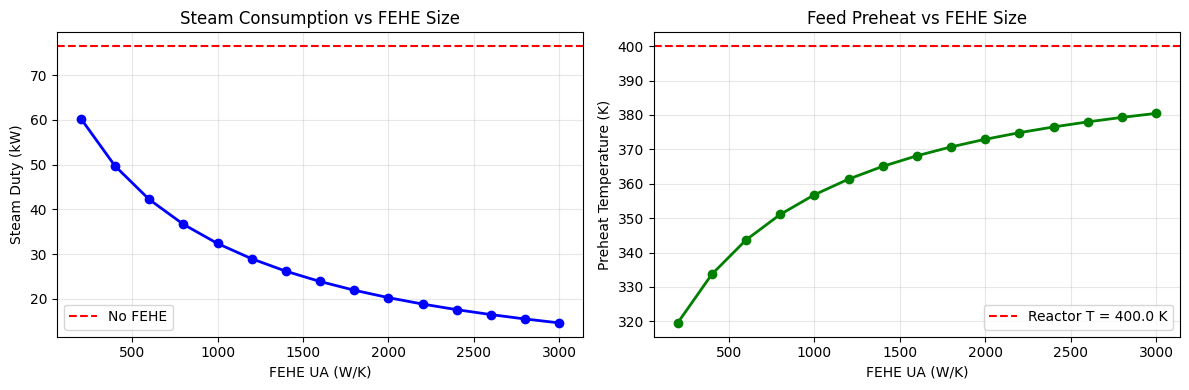

In [13]:
UA_range = jnp.linspace(200, 3000, 15)
steam_duties = []
preheat_temps = []

for UA in UA_range:
    result = process_with_heat_integration(float(UA))
    steam_duties.append(result['heater_duty'])
    preheat_temps.append(result['T_preheat'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Base case steam duty
base_steam = float(heater_info['Q'])

axes[0].plot(UA_range, jnp.array(steam_duties)/1000, 'b-o', linewidth=2, markersize=6)
axes[0].axhline(y=base_steam/1000, color='r', linestyle='--', label='No FEHE')
axes[0].set_xlabel('FEHE UA (W/K)')
axes[0].set_ylabel('Steam Duty (kW)')
axes[0].set_title('Steam Consumption vs FEHE Size')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(UA_range, preheat_temps, 'g-o', linewidth=2, markersize=6)
axes[1].axhline(y=T_reactor, color='r', linestyle='--', label=f'Reactor T = {T_reactor} K')
axes[1].set_xlabel('FEHE UA (W/K)')
axes[1].set_ylabel('Preheat Temperature (K)')
axes[1].set_title('Feed Preheat vs FEHE Size')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Optimization: Minimize Total Annual Cost

Use gradients to optimize heat exchanger design.

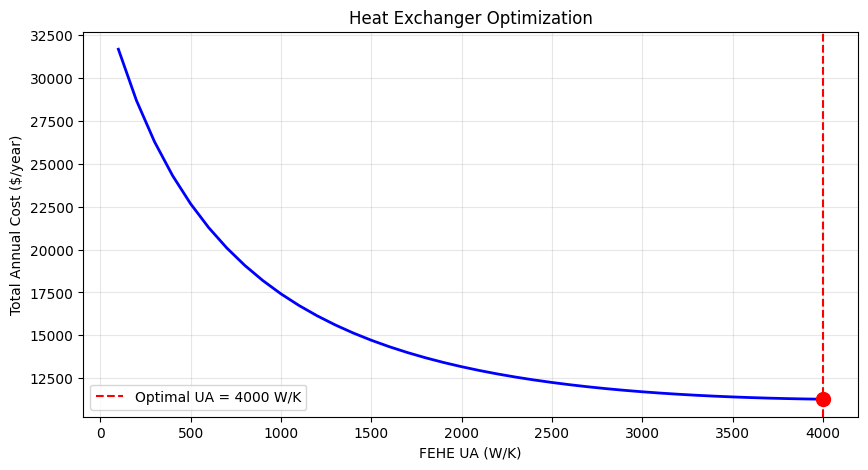

Optimal FEHE UA: 4000 W/K
Optimal Area:    8.00 m²
Minimum TAC:     $11,266/year


In [14]:
def total_annual_cost(UA):
    """Calculate total annual cost as function of FEHE UA.
    
    TAC = Capital cost (annualized) + Operating cost (utilities)
    """
    # Capital cost: assume area = UA / U, with U = 500 W/m²·K
    U = 500.0  # W/m²·K
    A = UA / U  # m²
    
    # Equipment cost correlation: C = a * A^b
    # Typical for shell-and-tube: $1000/m² base
    equipment_cost = 5000.0 + 1000.0 * A  # $
    
    # Installed cost (Lang factor ~ 3)
    installed_cost = 3.0 * equipment_cost
    
    # Annualize over 10 years at 10% interest
    crf = 0.10 * (1.10**10) / ((1.10**10) - 1)  # Capital recovery factor
    annual_capital = installed_cost * crf
    
    # Operating cost: steam at $15/GJ, 8000 hours/year
    # Simulate to get steam duty
    cold_feed = make_stream({"A": 10.0, "B": 0.0}, T=298.0, P=101325.0)
    hot_product = make_stream({"A": 2.0, "B": 8.0}, T=400.0, P=101325.0)  # Approx reactor outlet
    
    # FEHE
    fehe = CounterCurrentHX(HeatExchangerParams(Cp_hot=77.5, Cp_cold=75.0))
    _, preheated, info = fehe(hot_product, cold_feed, UA=UA)
    
    # Trim heater duty
    T_preheat = preheated["T"]
    F_total = 10.0  # mol/s
    Cp = 75.0  # J/mol·K
    steam_duty = F_total * Cp * (400.0 - T_preheat)  # W
    
    # Annual steam cost
    steam_price = 15.0  # $/GJ
    hours_per_year = 8000.0
    annual_steam = steam_duty * hours_per_year * 3600 / 1e9 * steam_price  # $/year
    
    return annual_capital + annual_steam

# Evaluate TAC over range of UA
UA_range = jnp.linspace(100, 4000, 40)
TAC_values = [float(total_annual_cost(jnp.array(ua))) for ua in UA_range]

# Find minimum
min_idx = jnp.argmin(jnp.array(TAC_values))
optimal_UA = float(UA_range[min_idx])
min_TAC = TAC_values[min_idx]

plt.figure(figsize=(10, 5))
plt.plot(UA_range, TAC_values, 'b-', linewidth=2)
plt.axvline(x=optimal_UA, color='r', linestyle='--', label=f'Optimal UA = {optimal_UA:.0f} W/K')
plt.scatter([optimal_UA], [min_TAC], color='r', s=100, zorder=5)
plt.xlabel('FEHE UA (W/K)')
plt.ylabel('Total Annual Cost ($/year)')
plt.title('Heat Exchanger Optimization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal FEHE UA: {optimal_UA:.0f} W/K")
print(f"Optimal Area:    {optimal_UA/500:.2f} m²")
print(f"Minimum TAC:     ${min_TAC:,.0f}/year")

### 5.1 Gradient-Based Optimization

Gradient-based optimization:
  Optimal UA:  3733.9 W/K
  Optimal TAC: $11,320/year
  Iterations:  50


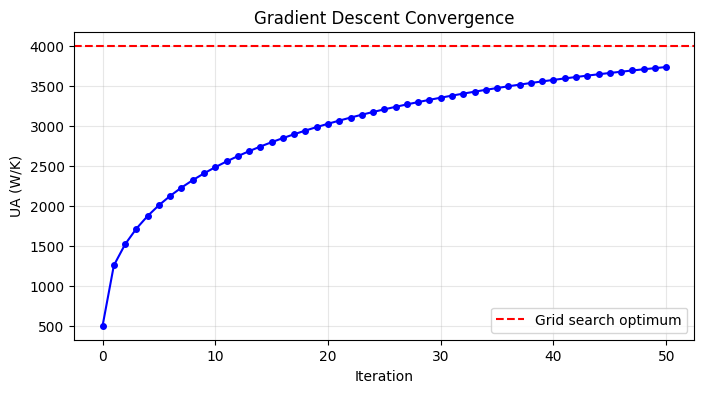

In [15]:
# Use JAX gradients to optimize
grad_tac = jax.grad(total_annual_cost)

# Simple gradient descent
UA = jnp.array(500.0)  # Initial guess
learning_rate = 50.0
history = [float(UA)]

for i in range(50):
    g = grad_tac(UA)
    UA = UA - learning_rate * g
    UA = jnp.clip(UA, 100.0, 5000.0)  # Bounds
    history.append(float(UA))
    
    if abs(float(g)) < 0.1:
        break

print(f"Gradient-based optimization:")
print(f"  Optimal UA:  {float(UA):.1f} W/K")
print(f"  Optimal TAC: ${float(total_annual_cost(UA)):,.0f}/year")
print(f"  Iterations:  {len(history)-1}")

# Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(history, 'b-o', markersize=4)
plt.axhline(y=optimal_UA, color='r', linestyle='--', label='Grid search optimum')
plt.xlabel('Iteration')
plt.ylabel('UA (W/K)')
plt.title('Gradient Descent Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary

This notebook demonstrated:

1. **Heaters/Coolers**: Single-stream heat exchange with utilities
   - Duty mode, temperature mode, and rating mode
   
2. **Two-Stream Heat Exchangers**: 
   - Counter-current achieves higher effectiveness
   - Both fully differentiable using effectiveness-NTU
   
3. **Design Methods**:
   - LMTD method when temperatures are known
   - Effectiveness-NTU method when flow rates are known
   
4. **Heat Integration**:
   - Feed-effluent heat exchanger (FEHE) reduces utility consumption
   - Trade-off between capital (larger HX) and operating (utility) costs
   
5. **Optimization**:
   - JAX gradients enable efficient optimization
   - Can minimize total annual cost (capital + operating)